# Credit-card fraud, continuous features only

This notebook asks the same question as the synthetic one, on a different table: is this transaction harder for a network trained on normal rows to rebuild than almost all later normal rows?

The table is the public Kaggle Credit Card Fraud Detection file (`mlg-ulb/creditcardfraud`, `creditcard.csv`): 284,807 European card payments from two days in 2013, with 492 fraud labels. `V1`–`V28` are anonymized principal components supplied by the dataset. This notebook does not refit that PCA, and it cannot tell you what those axes meant to the original features.

This is normal-only / semi-supervised anomaly detection. `Class` is used to build a clean normal reference and to score the holdout. It is not an input to the loss. The synthetic notebook is a different problem: five hand-built continuous fields plus merchant and device heads. Here the input is 30 continuous columns and there is no categorical cross-entropy.


## Setup

`MAX_TRAIN_NORMALS` is the only training-size knob. Leave it as `None` to use every normal row in the training window. Set an integer to draw a seeded subset of those normals for the scaler and the VAE. Evaluation fraud is never capped. The training cell prints when the cap is active.

`beta` is 0.01, not the synthetic notebook's 0.1. These columns are only weakly dependent once each one has been standardized, and a 6-dimensional code is a hard bottleneck on 30 of them. With `beta=0.1` and a narrow trunk the encoder collapses onto the unit Gaussian and the decoder rebuilds the training mean. The smaller weight lets reconstruction move first. KL is still in the training loss and still absent from the score.


In [1]:
%matplotlib inline
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

ROOT = Path.cwd().resolve()
if not (ROOT / "src" / "fraudvae").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from fraudvae.loss import LossConfig, VAELoss
from fraudvae.model import TabularVAE
from fraudvae.real_data import (
    FEATURE_COLUMNS,
    SENSITIVITY_PERCENTILES,
    CreditCardPreprocessor,
    chronological_split,
    detection_metrics,
    creditcard_schema,
    encode_mu,
    fit_isolation_forest,
    fit_visualization_pca,
    format_metrics,
    isolation_anomaly_scores,
    load_creditcard_csv,
    tensor_dataset,
    threshold_sensitivity,
)
from fraudvae.score import ReconstructionScorer
from fraudvae.train import VAETrainer, set_seed

SEED = 42
EPOCHS = 12
BATCH_SIZE = 1024
LATENT_DIM = 6
HIDDEN_DIM = 128
LEARNING_RATE = 1e-3
BETA = 0.01
MAX_TRAIN_NORMALS = None
PCA_FIT_ROWS = 8000
PLOT_NORMALS = 4000
PRIMARY_PERCENTILE = 99.0
DATA_PATH = ROOT / "data" / "creditcard.csv"

set_seed(SEED)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
run_started = time.perf_counter()
print(f"root={ROOT}")


root=/workspace


## Data

The CSV is not in git. `data/` is ignored, and so is `kaggle.json`. If `data/creditcard.csv` is missing, the next cell asks `kagglehub` for `mlg-ulb/creditcardfraud`. When that call requires a login, accept the dataset rules on Kaggle and put your token in `~/.kaggle/kaggle.json`. Do not commit the token or the CSV.


In [2]:
if not DATA_PATH.is_file():
    try:
        import kagglehub
        from shutil import copy2

        downloaded = Path(kagglehub.dataset_download("mlg-ulb/creditcardfraud"))
        source = next(downloaded.rglob("creditcard.csv"))
        DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
        copy2(source, DATA_PATH)
    except Exception as exc:
        raise RuntimeError(
            "Could not load data/creditcard.csv and could not download "
            "mlg-ulb/creditcardfraud. Accept the dataset rules on Kaggle, "
            "place creditcard.csv at data/creditcard.csv, and if the API asks "
            "for a token put it in ~/.kaggle/kaggle.json. Do not commit either file. "
            f"Underlying error: {type(exc).__name__}: {exc}"
        ) from exc

frame = load_creditcard_csv(DATA_PATH)
n_fraud = int((frame["Class"] == 1).sum())
print(f"rows={len(frame)}  fraud={n_fraud}  normal={len(frame) - n_fraud}")
print(f"fraud rate={n_fraud / len(frame):.4%}")
print("columns:", ", ".join(frame.columns))
print(frame[["Time", "V1", "V2", "Amount", "Class"]].head(3).to_string(index=False))


rows=284807  fraud=492  normal=284315
fraud rate=0.1727%
columns: Time, V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11, V12, V13, V14, V15, V16, V17, V18, V19, V20, V21, V22, V23, V24, V25, V26, V27, V28, Amount, Class
 Time        V1        V2  Amount  Class
  0.0 -1.359807 -0.072781  149.62      0
  0.0  1.191857  0.266151    2.69      0
  1.0 -1.358354 -1.340163  378.66      0


## What the columns are

`Time` is seconds since the first transaction in the file. `Amount` is the payment. `Class` is 1 for fraud and 0 otherwise. `V1`–`V28` are principal components the dataset authors computed from the confidential original fields and then released without the loading matrix. A large `V14` is not a merchant, a country, or a time of day. It is one coordinate in their PCA. Standardizing those columns again, below, is for the Huber loss. It is not a second scientific PCA.


## Chronological split

Random splits leak the future into training: a normal pattern from late on day two would teach the model how to rebuild rows it is then asked to judge. This cut sorts by `Time`, breaking ties by the original row order, and then takes positions:

- first 60% of rows: candidate training window
- next 20%: calibration window
- last 20%: evaluation window

Training and calibration keep `Class=0` only. Fraud in those windows is dropped, not moved into the holdout and not shown to the optimizer. Evaluation keeps every row in the last window, normal and fraud. Most fraud in this file sits early, so the holdout contains fewer than 20% of the 492 fraud labels. That is a property of the clock, not a silent filter on the test fraud.

`VAETrainer` receives the label tensor and does not pass it to `TabularVAE` or `VAELoss`.


In [3]:
splits = chronological_split(frame, max_train_normals=MAX_TRAIN_NORMALS, seed=SEED)
train_ids = set(splits.train_normal["row_id"])
calibration_ids = set(splits.calibration_normal["row_id"])
evaluation_ids = set(splits.evaluation["row_id"])
assert train_ids.isdisjoint(calibration_ids)
assert train_ids.isdisjoint(evaluation_ids)
assert calibration_ids.isdisjoint(evaluation_ids)
assert (splits.train_normal["Class"] == 0).all()
assert (splits.calibration_normal["Class"] == 0).all()
assert splits.evaluation["Time"].is_monotonic_increasing
assert int((splits.evaluation["Class"] == 1).sum()) == splits.evaluation_fraud

print(f"ordered rows={splits.n_ordered}")
print(f"train normals={len(splits.train_normal)}  fraud excluded from train={splits.train_fraud_excluded}")
print(
    f"calibration normals={len(splits.calibration_normal)}  "
    f"fraud excluded from calibration={splits.calibration_fraud_excluded}"
)
print(
    f"evaluation rows={len(splits.evaluation)}  "
    f"normal={(splits.evaluation['Class'] == 0).sum()}  fraud={splits.evaluation_fraud}"
)
print(f"train cap active={splits.subsampled_train}  MAX_TRAIN_NORMALS={MAX_TRAIN_NORMALS}")
if splits.subsampled_train:
    print(
        "Subsampling is active: the scaler and the VAE see a seeded subset of "
        "training-window normals. Calibration and evaluation are unchanged, "
        "including every evaluation fraud row."
    )
else:
    print("Subsampling is not active. Every training-window normal is used.")


ordered rows=284807
train normals=170524  fraud excluded from train=360
calibration normals=56904  fraud excluded from calibration=57
evaluation rows=56962  normal=56887  fraud=75
train cap active=False  MAX_TRAIN_NORMALS=None
Subsampling is not active. Every training-window normal is used.


## Preprocessing, fit on the training normals only

Thirty inputs, in this order: `Time`, `V1`–`V28`, `Amount`.

- `Amount` is `log1p`, then z-scored. It is right-skewed, and zero is a real amount (`log1p(0) = 0`).
- `Time` is z-scored and not logged. It is a clock that starts at 0, not a skewed magnitude.
- `V1`–`V28` are z-scored with the training-normal mean and population standard deviation. They are already PCA scores, and they are signed, so `log1p` does not apply. The z-score gives every column the same Huber scale: the kink at delta 1 is one training standard deviation of that column.

Calibration, evaluation, and any later score call reuse `mean_` and `std_`. They are not refit.


In [4]:
preprocessor = CreditCardPreprocessor().fit(splits.train_normal)
assert preprocessor.n_fit_rows_ == len(splits.train_normal)
print(preprocessor.describe())
train_x = preprocessor.transform(splits.train_normal)
calibration_x = preprocessor.transform(splits.calibration_normal)
evaluation_x = preprocessor.transform(splits.evaluation)
print(f"scaled train shape={train_x.shape}")
print(f"train scaled mean (should be ~0)={train_x.mean(axis=0)[:3].round(4)}")


fit on 170524 normal training rows
log1p then z-score: Amount
z-score only: Time, V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11, V12, V13, V14, V15, V16, V17, V18, V19, V20, V21, V22, V23, V24, V25, V26, V27, V28
mean_ and std_ are population statistics (ddof=0) of that transformed matrix


scaled train shape=(170524, 30)
train scaled mean (should be ~0)=[-0.  0. -0.]


## Model

`TabularVAE` is built with no categorical cardinalities, so it has no categorical heads and no dummy class. The encoder reads 30 numbers and emits six means and six log-variances. Training samples `z = mu + sigma * epsilon`. Scoring decodes `mu`, so a row does not get a new score on every call.

The training objective is still Huber + beta * KL. The cross-entropy term is zero because there are no heads. The anomaly score later is the sum of the 30 per-feature Huber terms. KL is not in that sum.


In [5]:
loss_config = LossConfig(lambda_cont=1.0, lambda_cat=1.0, beta=BETA, huber_delta=1.0)
model = TabularVAE(
    n_continuous=train_x.shape[1],
    cat_cardinalities=(),
    latent_dim=LATENT_DIM,
    hidden_dim=HIDDEN_DIM,
)
assert model.encoder[0].in_features == 30
assert len(model.categorical_heads) == 0
generator = torch.Generator()
generator.manual_seed(SEED)
train_loader = DataLoader(
    tensor_dataset(train_x, splits.train_normal["label"].to_numpy()),
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=generator,
)
train_started = time.perf_counter()
history = VAETrainer(model, VAELoss(loss_config), lr=LEARNING_RATE).fit(train_loader, epochs=EPOCHS)
train_seconds = time.perf_counter() - train_started
zero_reference = F.huber_loss(torch.zeros_like(torch.as_tensor(train_x)), torch.as_tensor(train_x), delta=1.0, reduction="mean")
print(f"training_seconds={train_seconds:.1f}")
print(f"final huber={history[-1]['huber']:.4f}  kl={history[-1]['kl']:.4f}")
print(f"huber of predicting the training mean (all zeros after scaling)={float(zero_reference):.4f}")
print("The trained Huber term should sit below that zero-predictor reference. If it does not, the code was not used.")


epoch 01  total=0.3221  huber=0.3004  cross_entropy=0.0000  kl=2.1720


epoch 02  total=0.2721  huber=0.2170  cross_entropy=0.0000  kl=5.5104


epoch 03  total=0.2516  huber=0.1859  cross_entropy=0.0000  kl=6.5715


epoch 04  total=0.2407  huber=0.1696  cross_entropy=0.0000  kl=7.1074


epoch 05  total=0.2339  huber=0.1599  cross_entropy=0.0000  kl=7.3963


...

epoch 08  total=0.2238  huber=0.1464  cross_entropy=0.0000  kl=7.7414


epoch 09  total=0.2219  huber=0.1440  cross_entropy=0.0000  kl=7.7937


epoch 10  total=0.2205  huber=0.1421  cross_entropy=0.0000  kl=7.8418


epoch 11  total=0.2189  huber=0.1401  cross_entropy=0.0000  kl=7.8816


epoch 12  total=0.2176  huber=0.1382  cross_entropy=0.0000  kl=7.9357
training_seconds=14.9
final huber=0.1382  kl=7.9357
huber of predicting the training mean (all zeros after scaling)=0.3469
The trained Huber term should sit below that zero-predictor reference. If it does not, the code was not used.


## Threshold

The primary cutoff is the 99th percentile of reconstruction scores on the calibration normals. A 95th percentile aims at flagging about 5% of normal traffic. On this file that would be thousands of false alarms for a fraud rate well under 1%, so 95 is a sensitivity row, not the operating point.

The percentile is computed on calibration scores only. Holdout fraud is not used to pick it. The table below reports 95, 97, 99, and 99.5 after the fact so the operating point can be compared with its neighbors. `high_risk` uses the stored 99th-percentile value.


In [6]:
scorer = ReconstructionScorer(
    model,
    preprocessor,
    loss_config,
    schema=creditcard_schema(),
    device="cpu",
)
threshold = scorer.fit_threshold(splits.calibration_normal, percentile=PRIMARY_PERCENTILE)
calibration_scores = scorer.reconstruction_errors(splits.calibration_normal)["reconstruction_error"].to_numpy()
evaluation_scored = scorer.reconstruction_errors(splits.evaluation)
evaluation_scores = evaluation_scored["reconstruction_error"].to_numpy()
evaluation_labels = splits.evaluation["label"].to_numpy()
assert len(evaluation_scores) == len(splits.evaluation)
assert np.allclose(
    evaluation_scores,
    scorer.reconstruction_errors(splits.evaluation)["reconstruction_error"].to_numpy(),
)

sensitivity = threshold_sensitivity(
    calibration_scores,
    evaluation_labels,
    evaluation_scores,
    percentiles=SENSITIVITY_PERCENTILES,
)
primary = detection_metrics(evaluation_labels, evaluation_scores, threshold)
print(f"primary percentile={PRIMARY_PERCENTILE}  threshold={threshold:.4f}")
print(format_metrics("VAE reconstruction score", primary))
print()
print("Threshold sensitivity (each cutoff is a calibration percentile):")
print(
    sensitivity[
        ["percentile", "threshold", "precision", "recall", "f1", "normal_fpr", "flagged_fraction", "tp", "fp", "fn", "tn"]
    ]
    .round(4)
    .to_string(index=False)
)


primary percentile=99.0  threshold=34.7925
VAE reconstruction score
threshold=34.7925
precision=0.0998  recall=0.5333  f1=0.1681
confusion tn=56526 fp=361 fn=35 tp=40
pr_auc=0.0809  roc_auc=0.9384
normal_fpr=0.0063  flagged_fraction=0.0070
support normal=56887  fraud=75
accuracy=0.9930  (misleading at this base rate)

Threshold sensitivity (each cutoff is a calibration percentile):
 percentile  threshold  precision  recall     f1  normal_fpr  flagged_fraction  tp   fp  fn    tn
       95.0    14.2839     0.0208  0.8000 0.0405      0.0497            0.0507  60 2826  15 54061
       97.0    18.2676     0.0398  0.8000 0.0758      0.0255            0.0265  60 1448  15 55439
       99.0    34.7925     0.0998  0.5333 0.1681      0.0063            0.0070  40  361  35 56526
       99.5    50.4868     0.1461  0.3467 0.2055      0.0027            0.0031  26  152  49 56735


## How to read the holdout numbers

Precision, recall, and F1 treat fraud as the positive class. The normal false-positive rate is the share of holdout normals at or above the cutoff. The flagged fraction is that same rule over every holdout row. PR-AUC and ROC-AUC rank the raw scores; they do not depend on the percentile.

Accuracy is a poor summary. Predicting "normal" for every row is already about 99.8% accurate, because fraud is rare. A high accuracy can hide a detector that never flags anyone. ROC-AUC can look strong when the typical fraud scores above the typical normal, while precision stays low because there are so many more normals than frauds. PR-AUC is the ranking summary that keeps that base rate in view.

The score is conformity to the normal-trained reconstruction, not a probability of fraud. A legitimate row with an unusual amount can score high. A fraud row that looks ordinary in these 30 columns can score low.


## Isolation Forest baseline

Same scaled normal training matrix, same calibration window, same holdout. The forest's `decision_function` is higher for points it considers normal, so the anomaly score used here is the negation. Its threshold is the 99th percentile of those scores on calibration normals, not the forest's `contamination` default and not a cutoff fit on test fraud. `max_samples` stays at sklearn's small default so the baseline is cheap.


In [7]:
forest = fit_isolation_forest(train_x, seed=SEED, n_estimators=100)
forest_calibration = isolation_anomaly_scores(forest, calibration_x)
forest_evaluation = isolation_anomaly_scores(forest, evaluation_x)
forest_threshold = float(np.percentile(forest_calibration, PRIMARY_PERCENTILE))
forest_primary = detection_metrics(evaluation_labels, forest_evaluation, forest_threshold)
forest_sensitivity = threshold_sensitivity(
    forest_calibration,
    evaluation_labels,
    forest_evaluation,
    percentiles=SENSITIVITY_PERCENTILES,
)
print(format_metrics("IsolationForest", forest_primary))
print()
print(
    forest_sensitivity[
        ["percentile", "threshold", "precision", "recall", "f1", "normal_fpr", "flagged_fraction", "tp", "fp", "fn", "tn"]
    ]
    .round(4)
    .to_string(index=False)
)


IsolationForest
threshold=0.0906
precision=0.0470  recall=0.2267  f1=0.0778
confusion tn=56542 fp=345 fn=58 tp=17
pr_auc=0.0382  roc_auc=0.9528
normal_fpr=0.0061  flagged_fraction=0.0064
support normal=56887  fraud=75
accuracy=0.9929  (misleading at this base rate)

 percentile  threshold  precision  recall     f1  normal_fpr  flagged_fraction  tp   fp  fn    tn
       95.0     0.0051     0.0257  0.7867 0.0497      0.0394            0.0403  59 2239  16 54648
       97.0     0.0315     0.0406  0.6933 0.0768      0.0216            0.0225  52 1228  23 55659
       99.0     0.0906     0.0470  0.2267 0.0778      0.0061            0.0064  17  345  58 56542
       99.5     0.1187     0.0289  0.0667 0.0403      0.0030            0.0030   5  168  70 56719


## Latent means, then a plot PCA

The 6-vector below is `mu` from the encoder. No epsilon is drawn. The scatter axes are a second, unrelated PCA: two components fit on a capped sample of normal-training latent means, then applied to the evaluation rows. It is not `V1`–`V2`, and it is not trained on fraud or on the holdout. Separation on this plane is a picture of where evaluation rows landed. The training target was reconstruction under a KL penalty, not this picture.

Normal points are downsampled for the scatter. Every evaluation fraud point is kept.


visualization PCA fit on normal-training mu only; components=2  fit_rows=8000
variance explained by the plot axes: 0.227, 0.179
plot shows 4000 eval normals and all 75 eval frauds


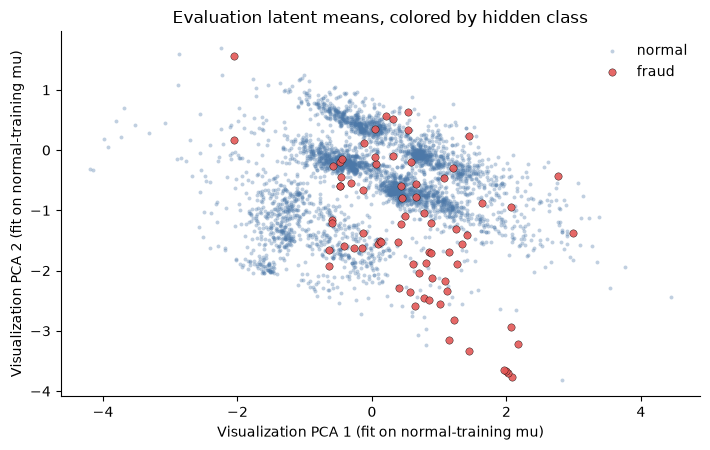

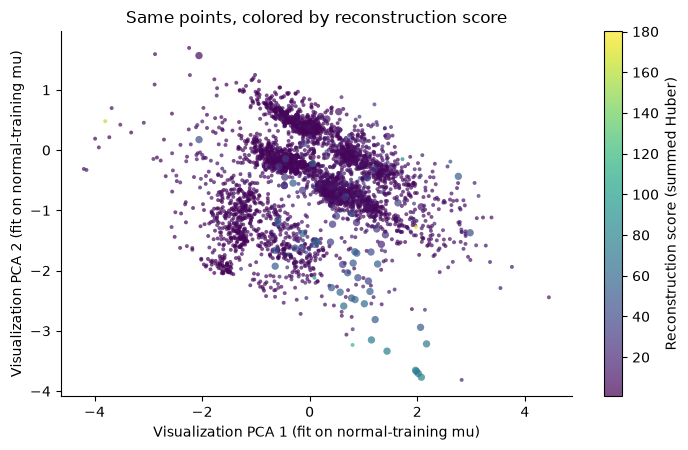

In [8]:
train_mu = encode_mu(model, train_x)
evaluation_mu = encode_mu(model, evaluation_x)
assert train_mu.shape == (len(train_x), LATENT_DIM)
assert evaluation_mu.shape == (len(evaluation_x), LATENT_DIM)
assert np.allclose(evaluation_mu[:64], encode_mu(model, evaluation_x[:64]))

visualization_pca = fit_visualization_pca(train_mu, max_rows=PCA_FIT_ROWS, seed=SEED)
evaluation_xy = visualization_pca.transform(evaluation_mu)
print(
    "visualization PCA fit on normal-training mu only; "
    f"components={visualization_pca.n_components_}  fit_rows={visualization_pca.n_samples_}"
)
print(
    "variance explained by the plot axes: "
    + ", ".join(f"{value:.3f}" for value in visualization_pca.explained_variance_ratio_)
)

rng = np.random.default_rng(SEED)
normal_positions = np.flatnonzero(evaluation_labels == 0)
fraud_positions = np.flatnonzero(evaluation_labels == 1)
if len(normal_positions) > PLOT_NORMALS:
    normal_positions = np.sort(rng.choice(normal_positions, size=PLOT_NORMALS, replace=False))
shown = np.concatenate([normal_positions, fraud_positions])
print(f"plot shows {len(normal_positions)} eval normals and all {len(fraud_positions)} eval frauds")

fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.scatter(
    evaluation_xy[normal_positions, 0],
    evaluation_xy[normal_positions, 1],
    s=8,
    c="#4c78a8",
    alpha=0.35,
    linewidths=0,
    label="normal",
)
ax.scatter(
    evaluation_xy[fraud_positions, 0],
    evaluation_xy[fraud_positions, 1],
    s=28,
    c="#e45756",
    alpha=0.9,
    linewidths=0.3,
    edgecolors="black",
    label="fraud",
)
ax.set_xlabel("Visualization PCA 1 (fit on normal-training mu)")
ax.set_ylabel("Visualization PCA 2 (fit on normal-training mu)")
ax.set_title("Evaluation latent means, colored by hidden class")
ax.legend(frameon=False, loc="best")
fig.tight_layout()
plt.show()

score_colors = evaluation_scores
fig, ax = plt.subplots(figsize=(7.2, 4.6))
points = ax.scatter(
    evaluation_xy[shown, 0],
    evaluation_xy[shown, 1],
    s=np.where(evaluation_labels[shown] == 1, 28, 8),
    c=score_colors[shown],
    cmap="viridis",
    alpha=0.7,
    linewidths=0,
)
fig.colorbar(points, ax=ax, label="Reconstruction score (summed Huber)")
ax.set_xlabel("Visualization PCA 1 (fit on normal-training mu)")
ax.set_ylabel("Visualization PCA 2 (fit on normal-training mu)")
ax.set_title("Same points, colored by reconstruction score")
fig.tight_layout()
plt.show()


## Score distribution, precision-recall, confusion

The histogram compares holdout normals with holdout fraud. The dashed line is the frozen calibration cutoff. The second panel zooms toward that cutoff so the normal mass is visible when a few large scores stretch the axis. The precision-recall curve includes a horizontal line at the holdout fraud rate, which is what "flag everyone" and "flag no one" have to beat in average precision terms only as a base-rate reference: average precision of a random ranker equals the fraud rate.


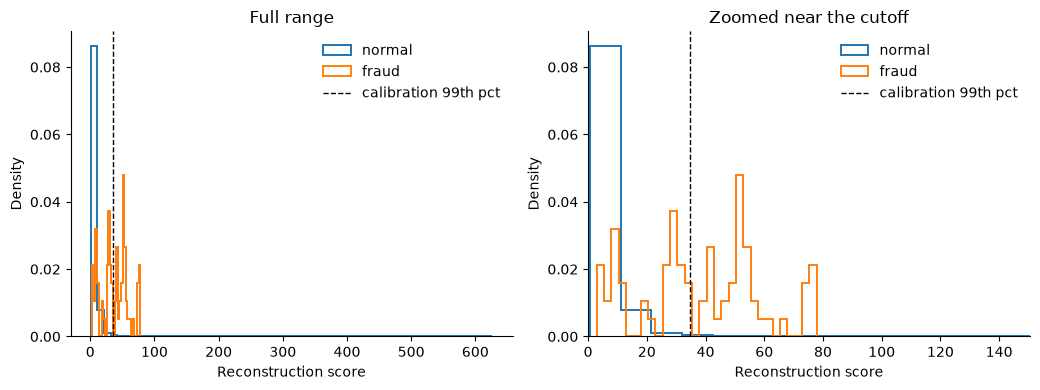

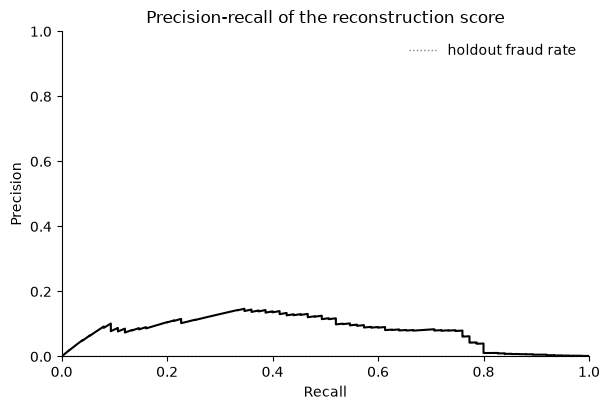

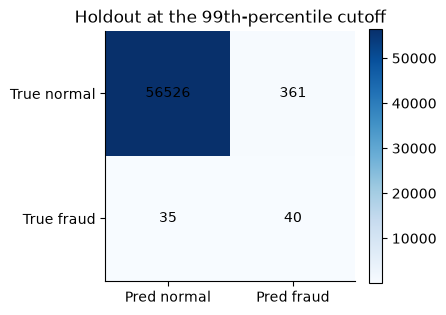

In [9]:
normal_scores = evaluation_scores[evaluation_labels == 0]
fraud_scores = evaluation_scores[evaluation_labels == 1]
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
for ax in axes:
    ax.hist(normal_scores, bins=60, density=True, histtype="step", linewidth=1.4, label="normal")
    ax.hist(fraud_scores, bins=30, density=True, histtype="step", linewidth=1.4, label="fraud")
    ax.axvline(threshold, color="black", linestyle="--", linewidth=1, label="calibration 99th pct")
    ax.set_xlabel("Reconstruction score")
    ax.set_ylabel("Density")
    ax.legend(frameon=False)
axes[0].set_title("Full range")
zoom = max(float(np.percentile(calibration_scores, 99.9)) * 1.5, float(threshold) * 1.2)
axes[1].set_xlim(0, zoom)
axes[1].set_title("Zoomed near the cutoff")
fig.tight_layout()
plt.show()

from sklearn.metrics import precision_recall_curve

curve_precision, curve_recall, _thresholds = precision_recall_curve(evaluation_labels, evaluation_scores)
fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.plot(curve_recall, curve_precision, color="black", linewidth=1.5)
ax.axhline(evaluation_labels.mean(), color="gray", linestyle=":", linewidth=1, label="holdout fraud rate")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("Precision-recall of the reconstruction score")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

confusion = np.array(
    [[primary["tn"], primary["fp"]], [primary["fn"], primary["tp"]]],
    dtype=float,
)
fig, ax = plt.subplots(figsize=(4.4, 3.8))
image = ax.imshow(confusion, cmap="Blues")
ax.set_xticks([0, 1], ["Pred normal", "Pred fraud"])
ax.set_yticks([0, 1], ["True normal", "True fraud"])
for row in range(2):
    for column in range(2):
        ax.text(column, row, f"{int(confusion[row, column])}", ha="center", va="center")
ax.set_title("Holdout at the 99th-percentile cutoff")
fig.colorbar(image, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()


## Where the reconstruction failed

Each cell is one feature's Huber term for one of the highest-scoring holdout rows. The terms sum to that row's continuous error, which is the whole score in this notebook. A bright `V12` means that anonymized component was hard to rebuild. It does not name a business cause. The class printed on the row is the hidden label, shown for diagnosis after scoring.


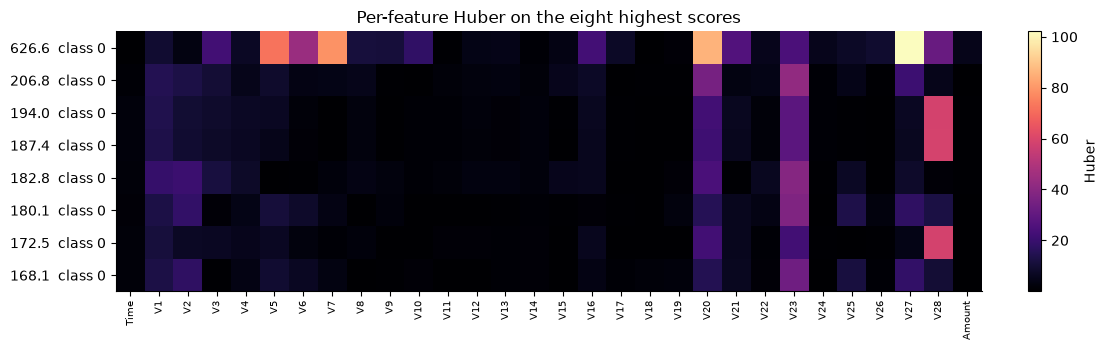

Largest average Huber terms on those eight rows:
V23    32.097000
V20    30.215000
V28    29.615999
V27    23.080000
V5     14.995000
V1     13.535000
V2     12.441000
V7     11.741000
total_runtime_seconds=18.3


In [10]:
top_positions = np.argsort(evaluation_scores)[-8:][::-1]
top_frame = splits.evaluation.iloc[top_positions]
contributions = scorer.continuous_feature_huber(top_frame)
assert np.allclose(
    contributions.to_numpy().sum(axis=1),
    evaluation_scores[top_positions],
)
fig, ax = plt.subplots(figsize=(11.2, 3.6))
image = ax.imshow(contributions.to_numpy(), aspect="auto", cmap="magma")
ax.set_yticks(
    range(len(top_positions)),
    [
        f"{score:.1f}  class {int(label)}"
        for score, label in zip(evaluation_scores[top_positions], evaluation_labels[top_positions])
    ],
)
ax.set_xticks(range(len(FEATURE_COLUMNS)), list(FEATURE_COLUMNS), rotation=90, fontsize=7)
ax.set_title("Per-feature Huber on the eight highest scores")
fig.colorbar(image, ax=ax, fraction=0.02, label="Huber")
fig.tight_layout()
plt.show()

mean_contribution = contributions.mean(axis=0).sort_values(ascending=False)
print("Largest average Huber terms on those eight rows:")
print(mean_contribution.head(8).round(3).to_string())
print(f"total_runtime_seconds={time.perf_counter() - run_started:.1f}")


## Limits

The fraud count is 492 out of 284,807, and the published features are PCA coordinates from one European card program in 2013. Nothing here is a current authorization stream. A model that separates this holdout has not been shown to separate a later year, another issuer, or features that still have names.

`Time` and `Amount` are the only columns with an ordinary meaning, and even `Time` is only "seconds from the first row," not a customer history. There is no cardholder id, merchant, device, or sequence. Two payments by the same person are two independent rows.

Using `Class` to drop fraud from training and calibration makes the reference set cleaner than a raw extract, and it also means the experiment is not label-free. If those labels were wrong, or if some fraud was left in the "normal" windows, the decoder would be taught to rebuild it and the score would go quiet. The threshold was frozen on this calibration window. A later week needs its own normal window. The number is not a calibrated probability.
